In [1]:
import numpy as np
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
ec_coords = np.genfromtxt('data/GBM39_5k_coordinates.txt')
hsr_coords = np.genfromtxt('data/GBM39HSR_5k_coordinates.txt')

ec_hic = np.load('data/ec_adj_mat_t25.npy')
hsr_hic = np.load('data/hsr_adj_mat_t25.npy')

ec_labels_df = pd.read_csv('outputs/ec_cluster_output.csv')

In [3]:
to_filter = 90
thres = np.percentile(ec_hic, to_filter)
vis_ec = ec_hic.copy()
vis_ec[vis_ec < thres] = 0
vis_ec[vis_ec > 0] = 1

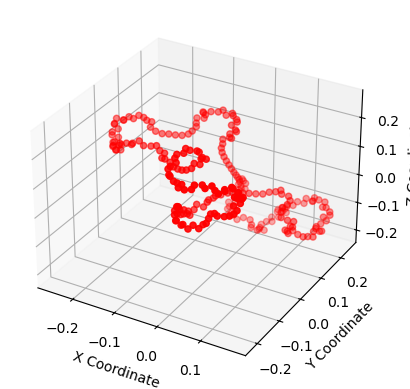

In [4]:
# Extract x, y, z columns
x = ec_coords[:, 0]
y = ec_coords[:, 1]
z = ec_coords[:, 2]

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='red', marker='o')

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

plt.show()


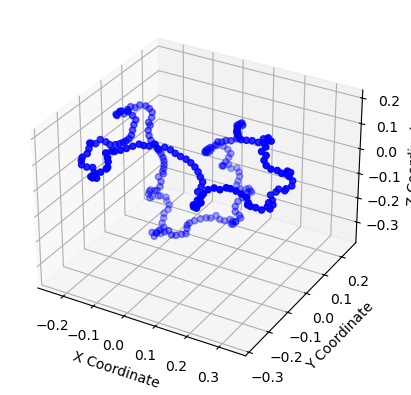

In [5]:
x = hsr_coords[:, 0]
y = hsr_coords[:, 1]
z = hsr_coords[:, 2]

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', marker='o')

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

plt.show()

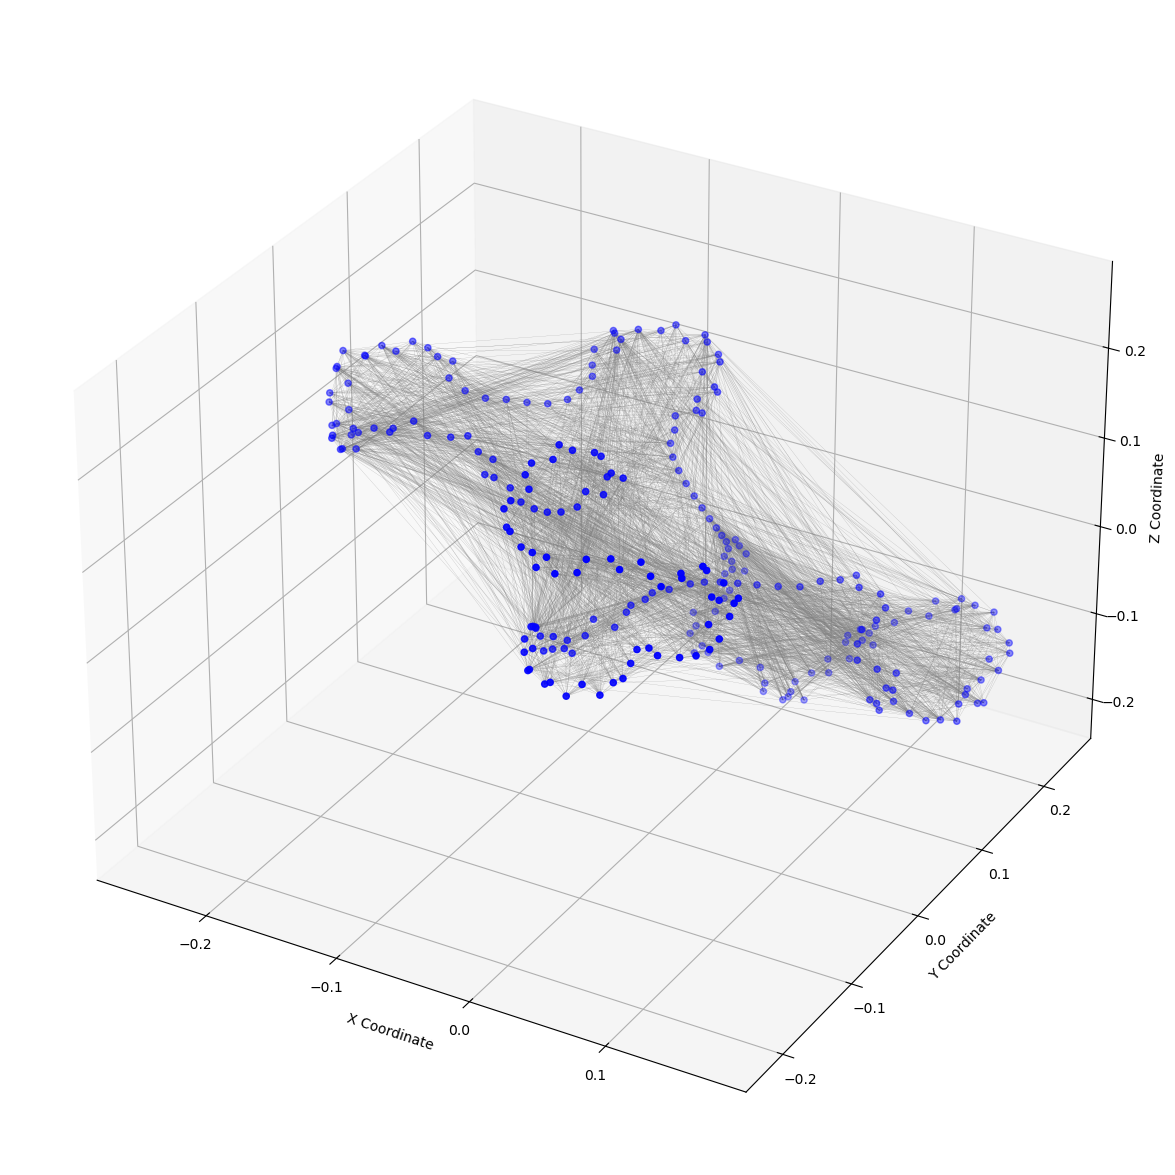

In [6]:
x = ec_coords[:, 0]
y = ec_coords[:, 1]
z = ec_coords[:, 2]

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='blue', marker='o')

num_points = len(x)
for i in range(num_points):
    for j in range(i + 1, num_points):
        if vis_ec[i, j] != 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], c='gray', linewidth=0.1)

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

# Show plot
plt.show()

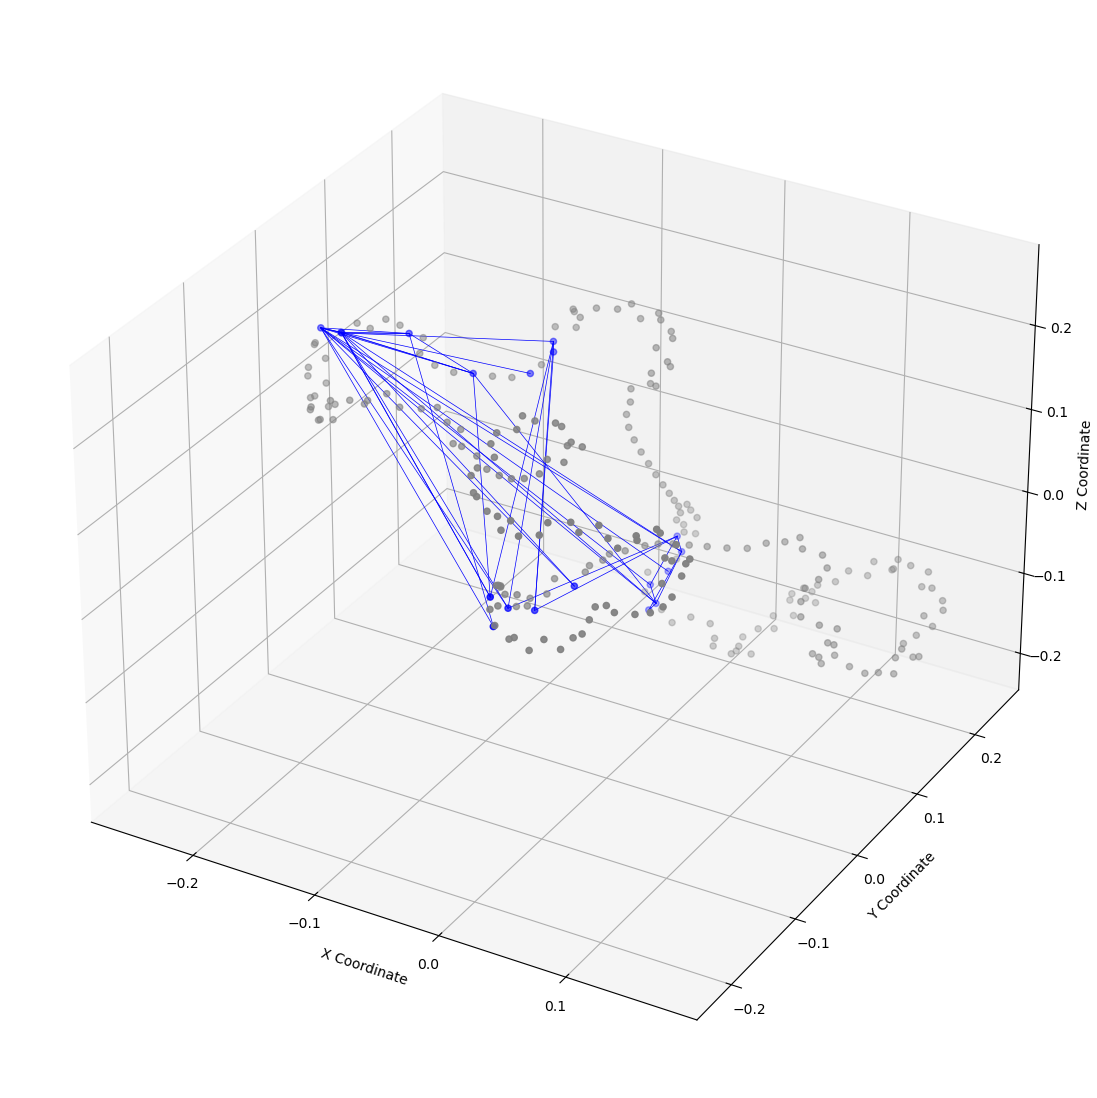

In [17]:
clusters = ec_labels_df['DB_labels']

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

point_colors = np.where(clusters == 1, 'blue', 'gray')

ax.scatter(x, y, z, c=point_colors, marker='o')

num_points = len(x)
for i in range(num_points):
    for j in range(i + 1, num_points):
        if ec_hic[i, j] != 0 and clusters[i] == 1 and clusters[j] == 1:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], c='blue', linewidth=0.5)

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

# Show plot
plt.savefig('images/cluster1_3d.png')
plt.show()

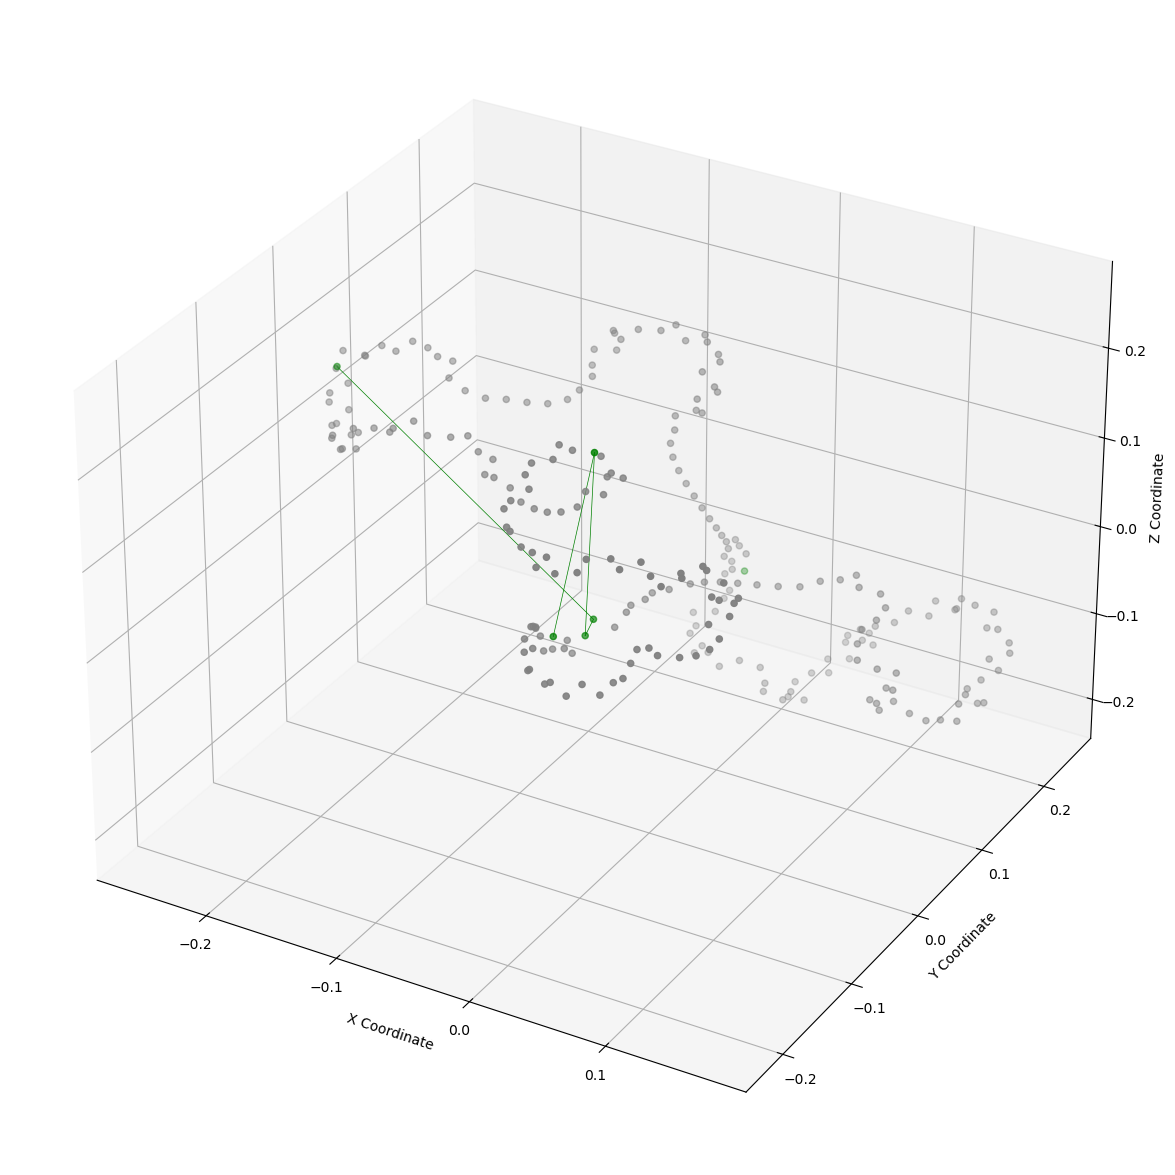

In [12]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

point_colors = np.where(clusters == 2, 'green', 'gray')

ax.scatter(x, y, z, c=point_colors, marker='o')

num_points = len(x)
for i in range(num_points):
    for j in range(i + 1, num_points):
        if ec_hic[i, j] != 0 and clusters[i] == 2 and clusters[j] == 2:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], c='green', linewidth=0.5)

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

# Show plot
plt.show()